# SUPERVISED LEARNING


In [114]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## Data Exploration

In [115]:
data = pd.read_csv('/content/property_price_data (1).csv')
data.head()

,Prop_Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,YrSold,SaleCondition,SalePrice
0,PRO504,20,RL,100.0,15537,Pave,NaN,IR1,Lvl,AllPub,...,0,161,0,NaN,GdWo,NaN,0,2010,Normal,288330
1,PRO102,60,RL,77.0,9534,Pave,NaN,Reg,Lvl,AllPub,...,0,0,0,NaN,NaN,NaN,0,2010,Normal,183164
2,PRO609,70,RL,NaN,12781,Pave,NaN,Reg,HLS,AllPub,...,0,0,0,NaN,NaN,NaN,0,2007,Alloca,362145
3,PRO1090,120,FV,37.0,3728,Pave,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,NaN,NaN,0,2006,Normal,196079
4,PRO820,120,RL,44.0,6606,Pave,NaN,IR1,Lvl,AllPub,...,0,0,0,NaN,NaN,NaN,0,2010,Partial,228515


In [144]:
data.shape

(970, 66)

In [117]:
data.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BsmtFullBath,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
count,970.000000,789.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,...,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000
mean,58.092784,69.447402,11208.956701,6.143299,5.547423,1971.496907,1984.741237,1079.728866,1532.874227,0.437113,...,474.715464,93.124742,48.015464,21.357732,4.261856,16.271134,4.152577,48.257732,2007.815464,184272.595876
std,42.962071,24.139429,10153.538896,1.396990,1.091443,30.247798,20.659310,463.970814,546.642210,0.518655,...,214.203638,122.884207,66.676218,59.281725,33.019578,58.939315,49.241171,595.105731,1.336156,82061.647461
min,20.000000,21.000000,1663.000000,1.000000,1.000000,1875.000000,1950.000000,0.000000,438.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000,35336.000000
25%,20.000000,57.000000,8147.500000,5.000000,5.000000,1954.000000,1966.250000,808.000000,1141.750000,0.000000,...,336.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000,132225.000000
50%,50.000000,68.000000,10174.500000,6.000000,5.000000,1974.000000,1994.000000,1008.000000,1469.000000,0.000000,...,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,165641.500000
75%,70.000000,80.000000,12482.250000,7.000000,6.000000,2000.000000,2004.000000,1324.000000,1792.000000,1.000000,...,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.000000,215268.250000
max,190.000000,313.000000,216301.000000,10.000000,9.000000,2009.000000,2010.000000,6110.000000,5642.000000,3.000000,...,1418.000000,736.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,2010.000000,758639.000000


In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    object 
 1   MSSubClass     970 non-null    int64  
 2   MSZoning       970 non-null    object 
 3   LotFrontage    789 non-null    float64
 4   LotArea        970 non-null    int64  
 5   Street         970 non-null    object 
 6   Alley          56 non-null     object 
 7   LotShape       970 non-null    object 
 8   LandContour    970 non-null    object 
 9   Utilities      970 non-null    object 
 10  LotConfig      970 non-null    object 
 11  LandSlope      970 non-null    object 
 12  Neighborhood   970 non-null    object 
 13  Condition1     970 non-null    object 
 14  Condition2     970 non-null    object 
 15  BldgType       970 non-null    object 
 16  PropStyle      970 non-null    object 
 17  OverallQual    970 non-null    int64  
 18  OverallCon

In [119]:
data.isna().sum()

,0
Prop_Id,0
MSSubClass,0
MSZoning,0
LotFrontage,181
LotArea,0
...,...
MiscFeature,941
MiscVal,0
YrSold,0
SaleCondition,0


In [120]:
data.duplicated().sum()

np.int64(0)

data.head() gives us the top 5 records of the database.  the shape of the data is (970,66) here we have 970 rows and 66 columns. data.describe() will give us the statistical values of the data. data.info() will give us the information about not null values and the datatypes of the particular columns. there aZre no duplicate values but we have some null values in the given data.

In [121]:
x = data.iloc[: , :-1]
y = data.iloc[: , -1]

In [122]:
x

,Prop_Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,YrSold,SaleCondition
0,PRO504,20,RL,100.0,15537,Pave,NaN,IR1,Lvl,AllPub,...,0,0,161,0,NaN,GdWo,NaN,0,2010,Normal
1,PRO102,60,RL,77.0,9534,Pave,NaN,Reg,Lvl,AllPub,...,0,0,0,0,NaN,NaN,NaN,0,2010,Normal
2,PRO609,70,RL,NaN,12781,Pave,NaN,Reg,HLS,AllPub,...,0,0,0,0,NaN,NaN,NaN,0,2007,Alloca
3,PRO1090,120,FV,37.0,3728,Pave,Pave,IR1,Lvl,AllPub,...,0,0,0,0,NaN,NaN,NaN,0,2006,Normal
4,PRO820,120,RL,44.0,6606,Pave,NaN,IR1,Lvl,AllPub,...,0,0,0,0,NaN,NaN,NaN,0,2010,Partial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,PRO162,60,RL,110.0,14777,Pave,NaN,IR1,Lvl,AllPub,...,0,0,0,0,NaN,NaN,NaN,0,2008,Normal
966,PRO693,60,RL,42.0,26949,Pave,NaN,IR1,Lvl,AllPub,...,0,0,0,0,NaN,NaN,NaN,0,2006,Normal
967,PRO674,20,RL,110.0,15573,Pave,NaN,Reg,Lvl,AllPub,...,0,0,200,0,NaN,NaN,NaN,0,2007,Normal
968,PRO750,50,RL,50.0,8367,Pave,NaN,Reg,Lvl,AllPub,...,185,0,0,0,NaN,NaN,NaN,0,2009,Normal


In [123]:
y

,SalePrice
0,288330
1,183164
2,362145
3,196079
4,228515
...,...
965,413403
966,336805
967,259324
968,96478


In [124]:
data["SalePrice"].describe()

,SalePrice
count,970.000000
mean,184272.595876
std,82061.647461
min,35336.000000
25%,132225.000000
50%,165641.500000
75%,215268.250000
max,758639.000000


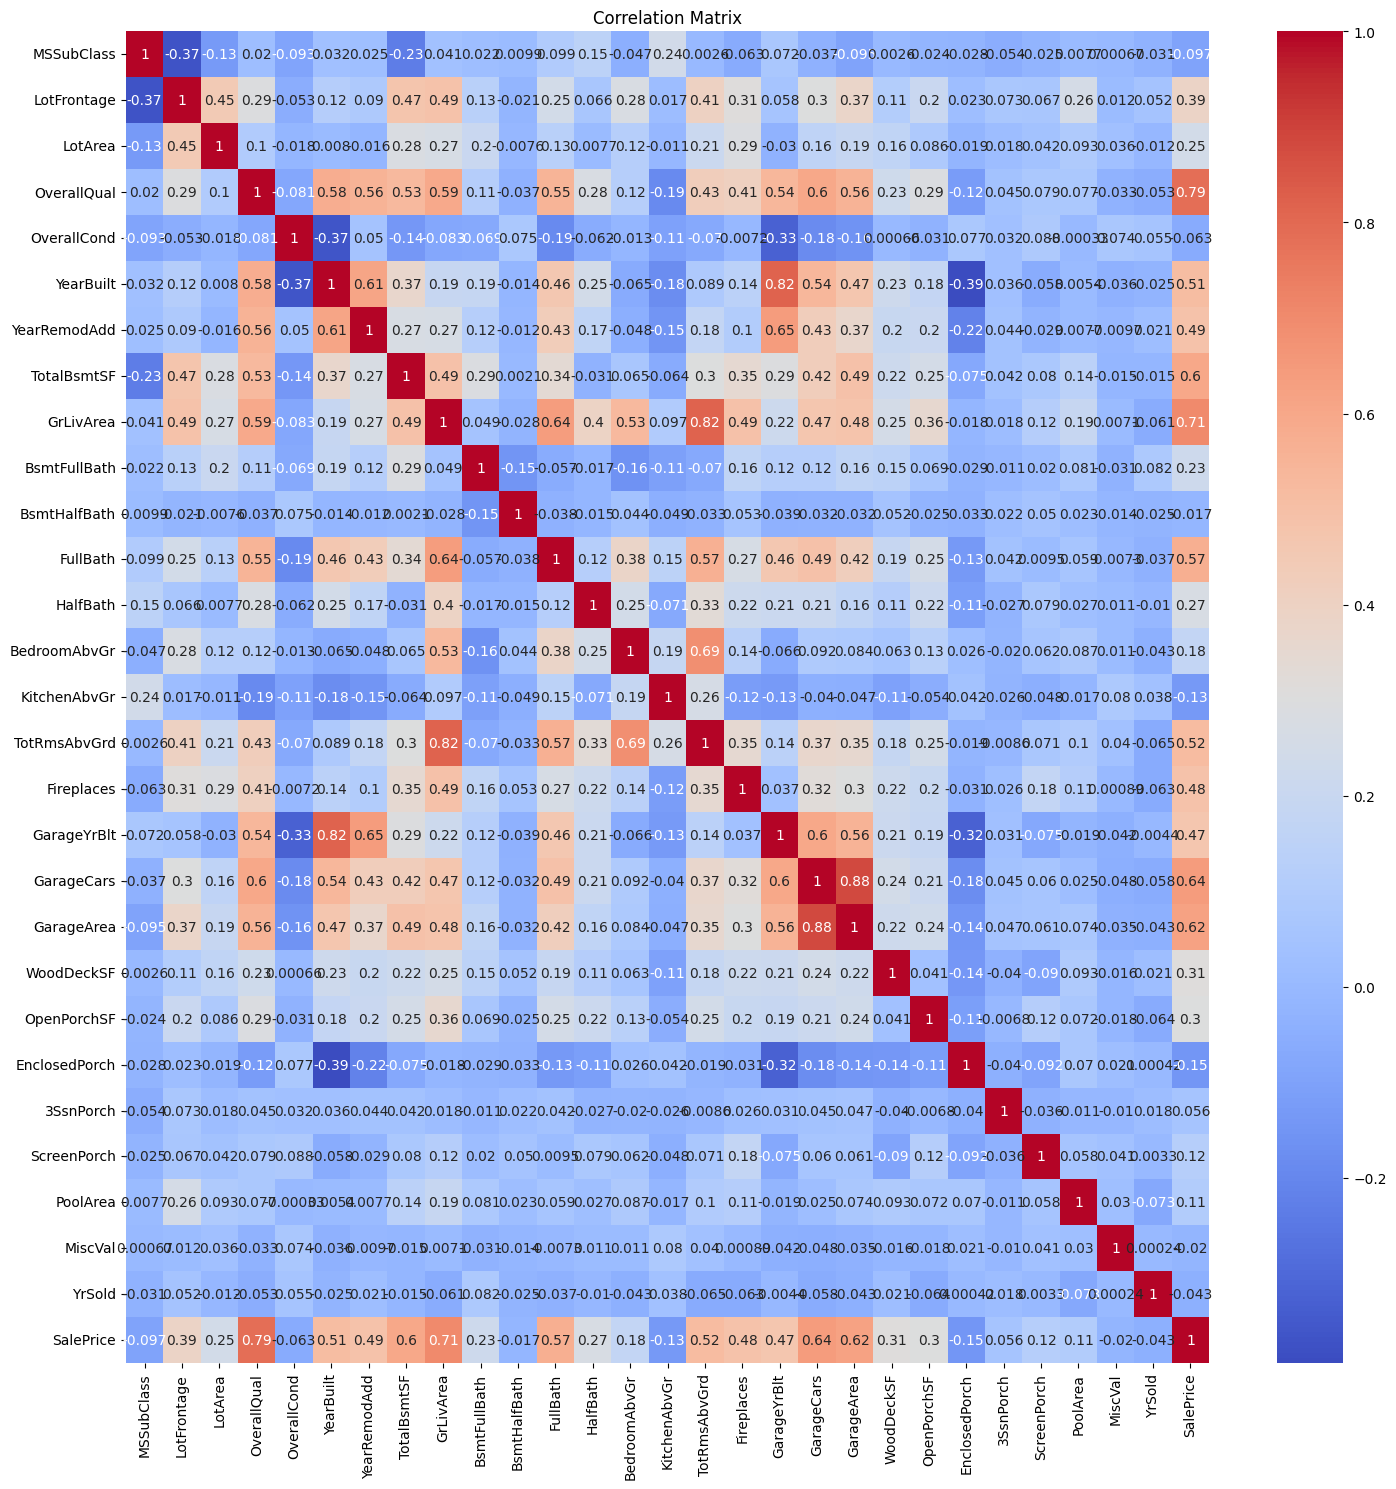

In [125]:
plt.figure(figsize=(15,15))
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

here with the help of correlation matrix we can see which variables are correlated to each other and we can also see how our targeted variable is correlated to other variables.

## Data Preprocessing

In [126]:
data.drop(['MiscFeature','PoolQC','Alley'], axis=1, inplace=True)

In [127]:
data.columns

Index(['Prop_Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'PropStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'TotalBsmtSF',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'Fence', 'MiscVal', 'YrSold',
       'SaleCondition', 'SalePrice

In [128]:
data.fillna(method='ffill', inplace=True)

/tmp/ipython-input-2866031220.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


impute the null values by the forwarded fill to handle the null values

In [129]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 66 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    object 
 1   MSSubClass     970 non-null    int64  
 2   MSZoning       970 non-null    object 
 3   LotFrontage    970 non-null    float64
 4   LotArea        970 non-null    int64  
 5   Street         970 non-null    object 
 6   LotShape       970 non-null    object 
 7   LandContour    970 non-null    object 
 8   Utilities      970 non-null    object 
 9   LotConfig      970 non-null    object 
 10  LandSlope      970 non-null    object 
 11  Neighborhood   970 non-null    object 
 12  Condition1     970 non-null    object 
 13  Condition2     970 non-null    object 
 14  BldgType       970 non-null    object 
 15  PropStyle      970 non-null    object 
 16  OverallQual    970 non-null    int64  
 17  OverallCond    970 non-null    int64  
 18  YearBuilt 

In [130]:
data.isna().sum().sum()

np.int64(0)

In [131]:
numeric_cols = data.select_dtypes(include=[np.number]).columns

q1 = data[numeric_cols].quantile(0.25)
q3 = data[numeric_cols].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_counts = {}

for col in numeric_cols:
    lower_outliers = (data[col] < lower_bound[col]).sum()
    upper_outliers = (data[col] > upper_bound[col]).sum()
    total_outliers = lower_outliers + upper_outliers
    outlier_counts[col] = total_outliers

for col, count in outlier_counts.items():
    print(f"'{col}' = {count}")

'MSSubClass' = 72
'LotFrontage' = 75
'LotArea' = 43
'OverallQual' = 1
'OverallCond' = 72
'YearBuilt' = 4
'YearRemodAdd' = 0
'TotalBsmtSF' = 42
'GrLivArea' = 25
'BsmtFullBath' = 1
'BsmtHalfBath' = 57
'FullBath' = 0
'HalfBath' = 0
'BedroomAbvGr' = 20
'KitchenAbvGr' = 43
'TotRmsAbvGrd' = 20
'Fireplaces' = 3
'GarageYrBlt' = 1
'GarageCars' = 1
'GarageArea' = 16
'WoodDeckSF' = 20
'OpenPorchSF' = 52
'EnclosedPorch' = 138
'3SsnPorch' = 20
'ScreenPorch' = 81
'PoolArea' = 7
'MiscVal' = 27
'YrSold' = 0
'SalePrice' = 47


With the help of this code we get to know the total outliers present in each column. We can also plot boxplot to see the ouliers in different columns

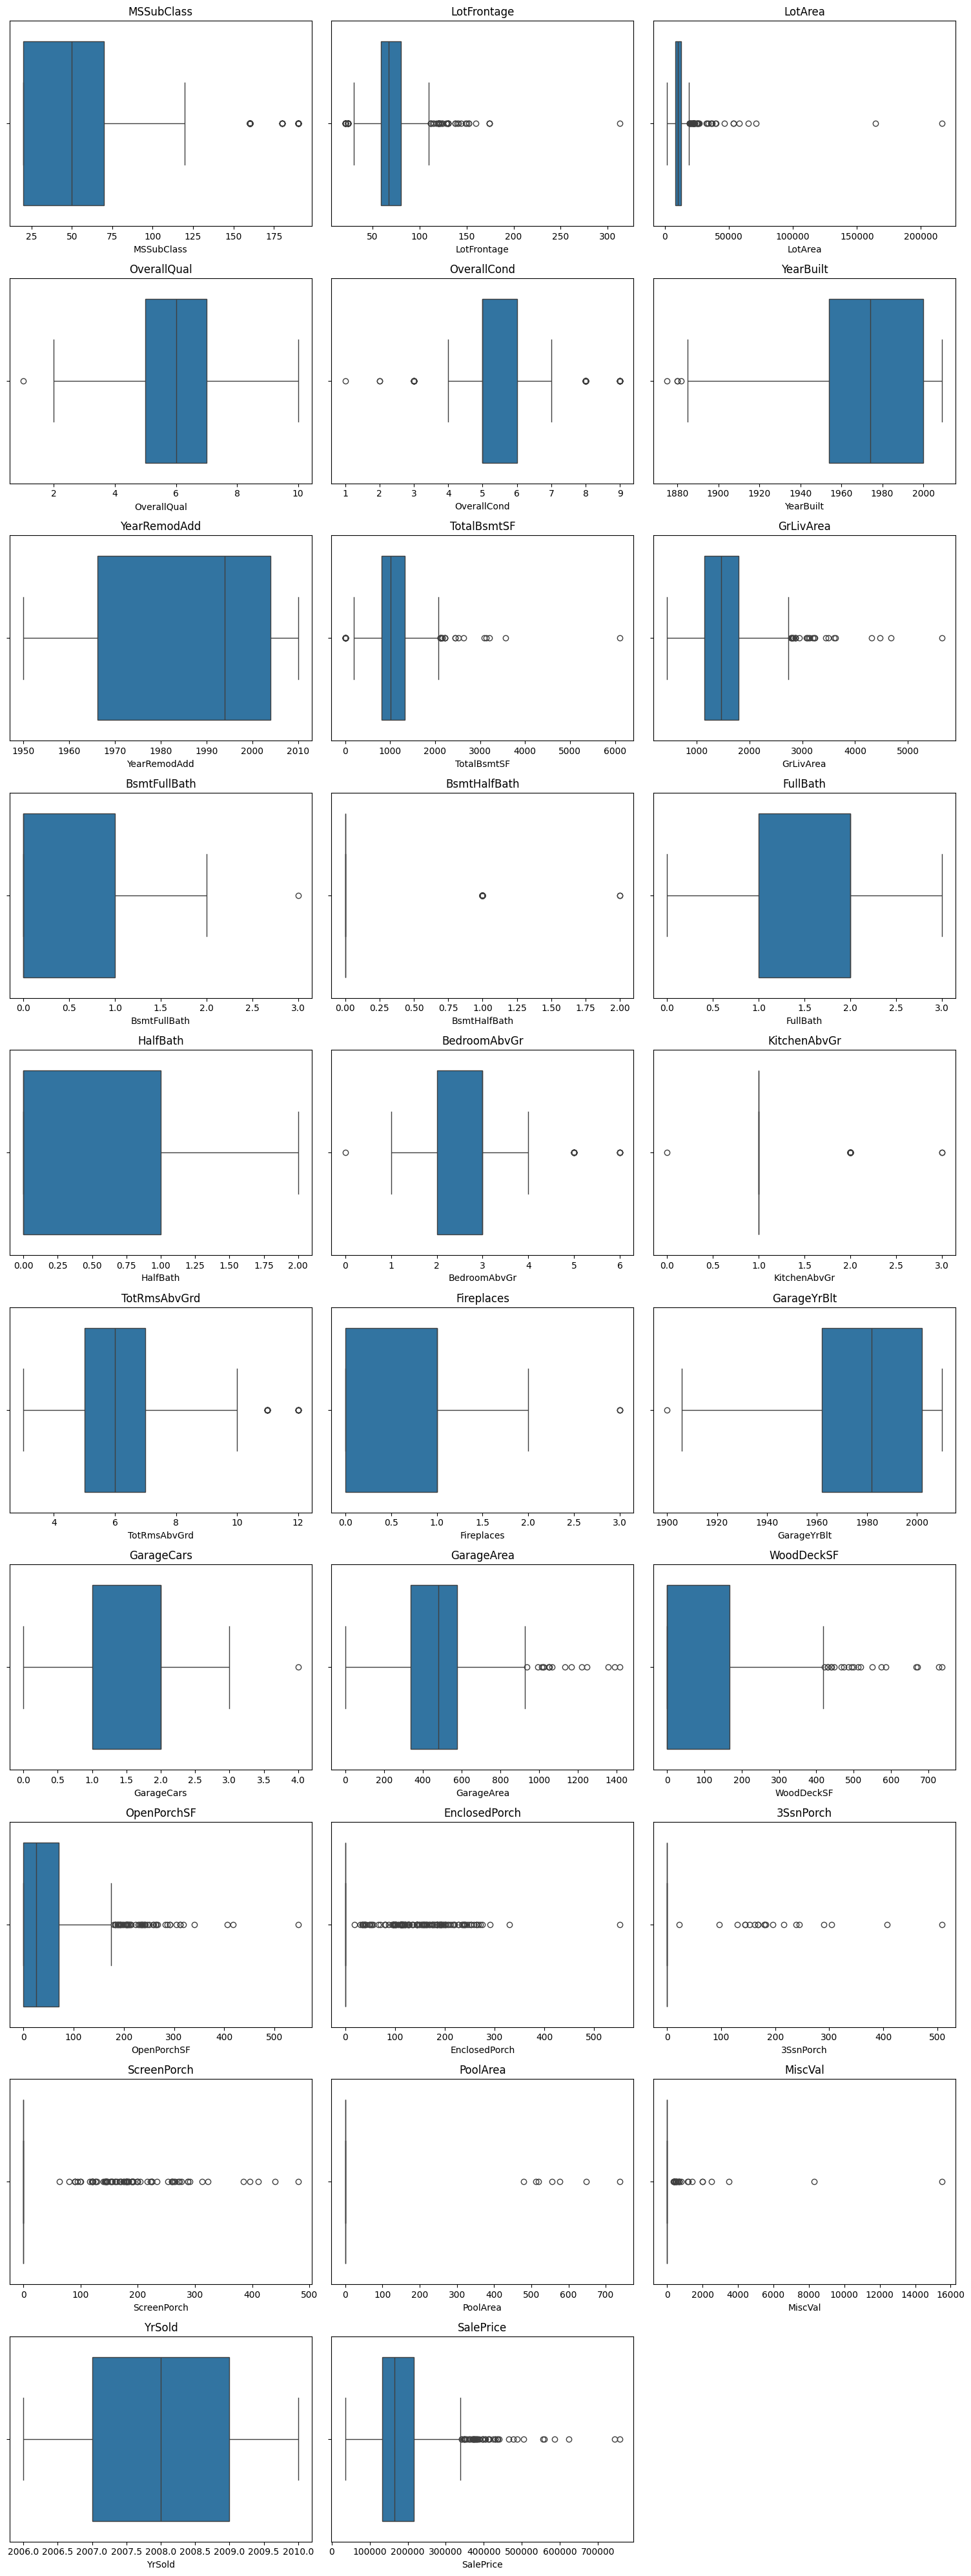

In [132]:
import math

n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / 3)

plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, 3, i + 1)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [133]:
for col in numeric_cols:
    data[col] = np.where(data[col] < lower_bound[col], lower_bound[col], data[col])
    data[col] = np.where(data[col] > upper_bound[col], upper_bound[col], data[col])

display(data[numeric_cols].describe())

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BsmtFullBath,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
count,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,...,970.000000,970.000000,970.000000,970.0,970.0,970.0,970.0,970.0,970.000000,970.000000
mean,56.185567,68.636598,10374.539304,6.144330,5.519588,1971.520619,1984.741237,1069.323711,1517.856057,0.436598,...,471.432990,90.883505,44.183505,0.0,0.0,0.0,0.0,0.0,2007.815464,180108.610180
std,38.043436,19.888146,3812.934862,1.393555,0.951956,30.177119,20.659310,409.361168,489.900760,0.516349,...,204.553785,114.834047,54.187776,0.0,0.0,0.0,0.0,0.0,1.336156,68027.313194
min,20.000000,27.500000,1663.000000,2.000000,3.500000,1885.000000,1950.000000,34.000000,438.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,2006.000000,35336.000000
25%,20.000000,59.000000,8147.500000,5.000000,5.000000,1954.000000,1966.250000,808.000000,1141.750000,0.000000,...,336.500000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,2007.000000,132225.000000
50%,50.000000,67.000000,10174.500000,6.000000,5.000000,1974.000000,1994.000000,1008.000000,1469.000000,0.000000,...,480.000000,0.000000,26.000000,0.0,0.0,0.0,0.0,0.0,2008.000000,165641.500000
75%,70.000000,80.000000,12482.250000,7.000000,6.000000,2000.000000,2004.000000,1324.000000,1792.000000,1.000000,...,576.000000,168.000000,70.000000,0.0,0.0,0.0,0.0,0.0,2009.000000,215268.250000
max,145.000000,111.500000,18984.375000,10.000000,7.500000,2009.000000,2010.000000,2098.000000,2767.375000,2.500000,...,935.250000,420.000000,175.000000,0.0,0.0,0.0,0.0,0.0,2010.000000,339833.125000


here we handled the ouliers by using iqr value. we can also use LabelEncoder to encode the values to convert object data types into int datatype

In [134]:
from sklearn.preprocessing import LabelEncoder
object_cols = data.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in object_cols:
    data[col] = le.fit_transform(data[col].astype(str))

In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 66 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    int64  
 1   MSSubClass     970 non-null    float64
 2   MSZoning       970 non-null    int64  
 3   LotFrontage    970 non-null    float64
 4   LotArea        970 non-null    float64
 5   Street         970 non-null    int64  
 6   LotShape       970 non-null    int64  
 7   LandContour    970 non-null    int64  
 8   Utilities      970 non-null    int64  
 9   LotConfig      970 non-null    int64  
 10  LandSlope      970 non-null    int64  
 11  Neighborhood   970 non-null    int64  
 12  Condition1     970 non-null    int64  
 13  Condition2     970 non-null    int64  
 14  BldgType       970 non-null    int64  
 15  PropStyle      970 non-null    int64  
 16  OverallQual    970 non-null    float64
 17  OverallCond    970 non-null    float64
 18  YearBuilt 

In [136]:
data.isnull().sum().sum()

np.int64(0)

In [137]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 66 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    int64  
 1   MSSubClass     970 non-null    float64
 2   MSZoning       970 non-null    int64  
 3   LotFrontage    970 non-null    float64
 4   LotArea        970 non-null    float64
 5   Street         970 non-null    int64  
 6   LotShape       970 non-null    int64  
 7   LandContour    970 non-null    int64  
 8   Utilities      970 non-null    int64  
 9   LotConfig      970 non-null    int64  
 10  LandSlope      970 non-null    int64  
 11  Neighborhood   970 non-null    int64  
 12  Condition1     970 non-null    int64  
 13  Condition2     970 non-null    int64  
 14  BldgType       970 non-null    int64  
 15  PropStyle      970 non-null    int64  
 16  OverallQual    970 non-null    float64
 17  OverallCond    970 non-null    float64
 18  YearBuilt 

In [138]:
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='SalePrice'>

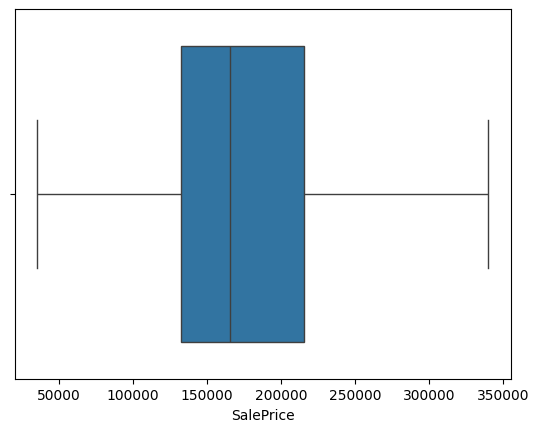

In [139]:
sns.boxplot(x=data['SalePrice'])

## Feature Engineering

<Axes: xlabel='SalePrice', ylabel='Count'>

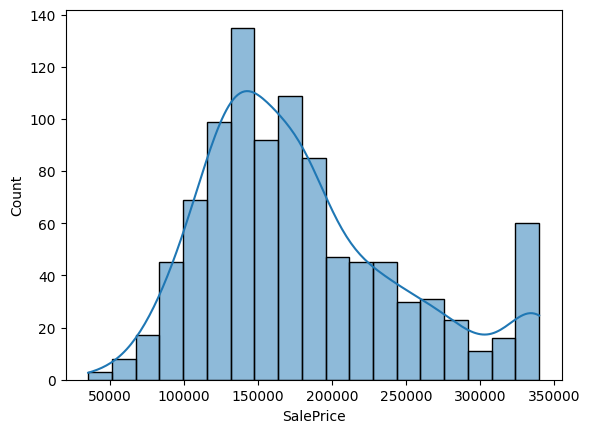

In [140]:
sns.histplot(data['SalePrice'], kde=True)

Here we can see data is slightly right skewed so here we will use standard scaler to scale the values.

## Model Development

In [141]:
X = data.drop(['SalePrice'], axis=1)
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)


(776, 65)
(194, 65)


In [145]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [146]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [147]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(r2)
print(mae)
print(rmse)

0.913346832800862
16297.382209641799
20371.824242781073


##  Business Insights

The Linear Regression model demonstrated strong predictive performance, achieving an R² score of 0.913, indicating that it explains approximately 91% of the variation in house sale prices. The model’s Mean Absolute Error (MAE) of around 16,297 and Root Mean Squared Error (RMSE) of approximately 20,371 show that the predictions are highly reliable and closely aligned with actual sale prices. The most influential factors identified through coefficient analysis include property quality measures such as OverallQual, size-related variables like GrLivArea and TotalBsmtSF, and functional features such as GarageCars and YearBuilt. These results highlight that improvements in overall construction quality, living area expansion, and modernized building design significantly increase property value. From a business perspective, real estate developers and property investors should prioritize quality enhancements, larger functional spaces, and modern infrastructure to maximize market returns.


However, as Linear Regression assumes linear relationships, the model may not capture complex non-linear interactions among features. Future improvements could involve using ensemble models such as Random Forest or Gradient Boosting, and integrating locational or economic variables for even more precise value prediction and market insight.